<a href="https://colab.research.google.com/github/binshee/streamflow/blob/main/streamflow.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM, Input
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import mean_squared_error, mean_absolute_error

In [5]:
# 1. Load Combined Dataset
df = pd.read_csv("USGS_Daymet_2003_2012_combined.csv")
df["Date"] = pd.to_datetime(df["date"])

# 2. Convert Rainfall from mm to inches and handle minor Daymet NaNs
df["R"] = (df["precipitation_mm_day"] / 25.4).ffill()
df["Q"] = df["streamflow_cfs"]

In [6]:
# 3. Train / Validation Split
train_df = df[(df["Date"] >= "2003-01-01") & (df["Date"] <= "2007-12-31")].copy()
val_df = df[(df["Date"] >= "2008-01-01") & (df["Date"] <= "2012-12-31")].copy()

In [7]:
# 4. Normalization using Assignment Bounds
train_df["R_norm"] = train_df["R"] / 6.8
train_df["Q_norm"] = train_df["Q"] / 29700.0

val_df["R_norm"] = val_df["R"] / 6.8
val_df["Q_norm"] = val_df["Q"] / 29700.0

In [8]:
# 5. Lag Feature Creation Function
def create_lagged_features(data_df, n_lags_R=3, m_lags_Q=3):
    X, y = [], []
    q_vals = data_df["Q_norm"].values
    r_vals = data_df["R_norm"].values
    max_lag = max(n_lags_R, m_lags_Q)

    for t in range(max_lag, len(data_df)):
        target = q_vals[t]
        q_lags = q_vals[t - m_lags_Q : t][::-1]
        r_lags = r_vals[t - n_lags_R : t][::-1]
        X.append(np.concatenate([q_lags, r_lags]))
        y.append(target)

    return np.array(X), np.array(y)

n_lags, m_lags = 3, 3
X_train, y_train = create_lagged_features(train_df, n_lags_R=n_lags, m_lags_Q=m_lags)
X_val, y_val = create_lagged_features(val_df, n_lags_R=n_lags, m_lags_Q=m_lags)

print(f"X_train shape: {X_train.shape} | y_train shape: {y_train.shape}")
print(f"X_val shape:   {X_val.shape} | y_val shape:   {y_val.shape}")

X_train shape: (1823, 6) | y_train shape: (1823,)
X_val shape:   (1824, 6) | y_val shape:   (1824,)


In [9]:
# 6. Train Standard ANN
model_ann = Sequential([
    Input(shape=(X_train.shape[1],)),
    Dense(32, activation='relu'),
    Dense(1, activation='linear')
])
model_ann.compile(optimizer=Adam(learning_rate=0.001), loss='mse', metrics=['mae'])
print("\n--- Training ANN ---")
model_ann.fit(X_train, y_train, validation_data=(X_val, y_val), epochs=30, batch_size=32, verbose=1)


--- Training ANN ---
Epoch 1/30
57/57 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0034 - mae: 0.0263 - val_loss: 0.0017 - val_mae: 0.0210
Epoch 2/30
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0019 - mae: 0.0155 - val_loss: 0.0010 - val_mae: 0.0151
Epoch 3/30
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0014 - mae: 0.0153 - val_loss: 7.9242e-04 - val_mae: 0.0132
Epoch 4/30
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0012 - mae: 0.0136 - val_loss: 6.4572e-04 - val_mae: 0.0117
Epoch 5/30
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0010 - mae: 0.0117 - val_loss: 5.5134e-04 - val_mae: 0.0119
Epoch 6/30
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 8.9804e-04 - mae: 0.0107 - val_loss: 4.8019e-04 - val_mae: 0.0098
Epoch 7/30
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 8.1469e-04 - mae: 0.0105 - val_loss: 4.3524e-04 - val_mae: 0.0091
Epoch 8/30
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 7.4194e-04 - mae: 0.0095 - val_loss: 4.1825e-04 - val_mae: 0.0095
Epoch 9/30
57/

In [10]:
# 7. Reshape & Train LSTM
X_train_lstm = X_train.reshape((X_train.shape[0], 3, 2))
X_val_lstm = X_val.reshape((X_val.shape[0], 3, 2))

model_lstm = Sequential([
    Input(shape=(3, 2)),
    LSTM(32, activation='relu'),
    Dense(1, activation='linear')
])
model_lstm.compile(optimizer=Adam(learning_rate=0.001), loss='mse', metrics=['mae'])
print("\n--- Training LSTM ---")
model_lstm.fit(X_train_lstm, y_train, validation_data=(X_val_lstm, y_val), epochs=30, batch_size=32, verbose=1)


--- Training LSTM ---
Epoch 1/30
57/57 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.0039 - mae: 0.0288 - val_loss: 0.0028 - val_mae: 0.0251
Epoch 2/30
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0031 - mae: 0.0247 - val_loss: 0.0019 - val_mae: 0.0214
Epoch 3/30
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0023 - mae: 0.0180 - val_loss: 0.0012 - val_mae: 0.0161
Epoch 4/30
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0018 - mae: 0.0155 - val_loss: 0.0010 - val_mae: 0.0158
Epoch 5/30
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0017 - mae: 0.0149 - val_loss: 9.6873e-04 - val_mae: 0.0142
Epoch 6/30
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0017 - mae: 0.0152 - val_loss: 9.5246e-04 - val_mae: 0.0137
Epoch 7/30
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0016 - mae: 0.0151 - val_loss: 9.3123e-04 - val_mae: 0.0131
Epoch 8/30
57/57 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0016 - mae: 0.0147 - val_loss: 0.0010 - val_mae: 0.0179
Epoch 9/30
57/57 ━━━━━━━━━━━━━━━━━━━

In [11]:
from google.colab import drive
drive.mount('/content/drive')
import matplotlib.pyplot as plt

Mounted at /content/drive


In [12]:
# --- 1. Predict on Validation Set ---
y_pred_ann = model_ann.predict(X_val) * 29700.0
y_pred_lstm = model_lstm.predict(X_val_lstm) * 29700.0
y_actual = y_val * 29700.0

# Dates corresponding to validation targets
val_dates = val_df["Date"].values[3:]

57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


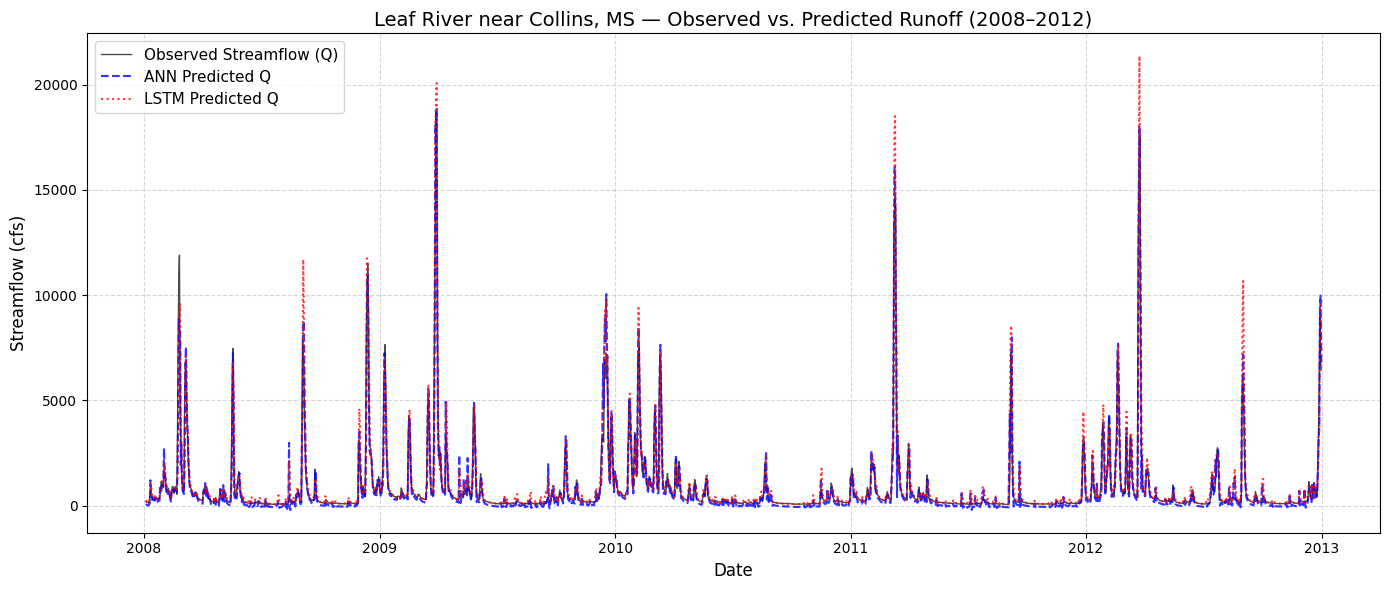

In [13]:
# --- 2. Plot 1: Observed vs. Predicted Hydrographs ---
plt.figure(figsize=(14, 6))
plt.plot(val_dates, y_actual, label="Observed Streamflow (Q)", color="black", alpha=0.7, linewidth=1)
plt.plot(val_dates, y_pred_ann, label="ANN Predicted Q", color="blue", alpha=0.8, linestyle="--")
plt.plot(val_dates, y_pred_lstm, label="LSTM Predicted Q", color="red", alpha=0.8, linestyle=":")

plt.title("Leaf River near Collins, MS — Observed vs. Predicted Runoff (2008–2012)", fontsize=14)
plt.xlabel("Date", fontsize=12)
plt.ylabel("Streamflow (cfs)", fontsize=12)
plt.legend(fontsize=11)
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.savefig("hydrograph_comparison.png", dpi=300)
plt.show()

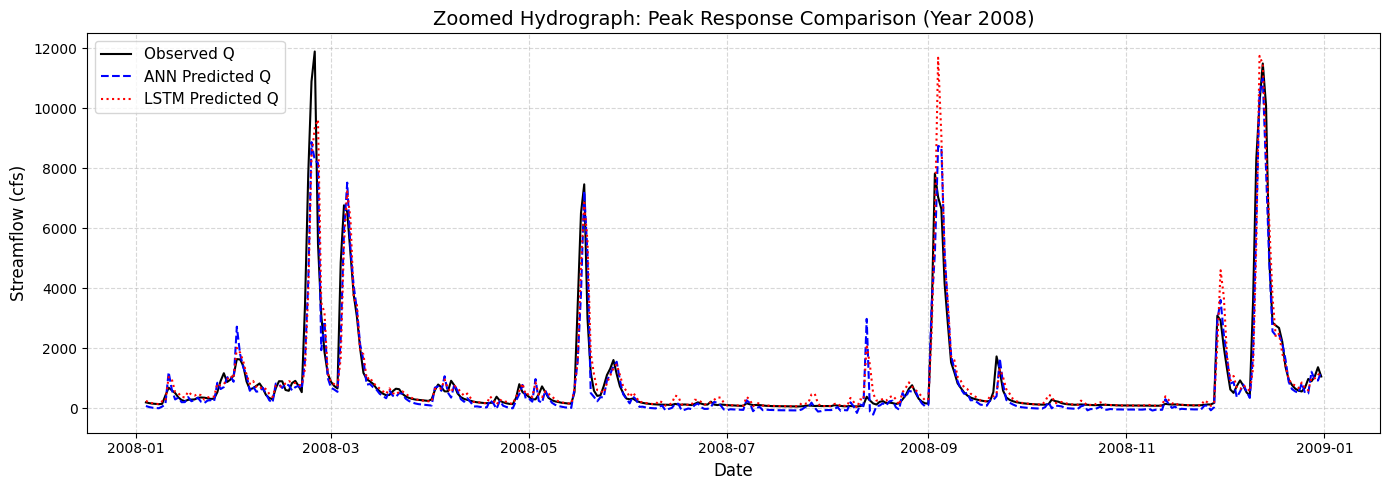

In [14]:
# --- 3. Plot 2: Single Year Zoomed-in Streamflow Peak (e.g., Year 2008) ---
mask_2008 = (val_dates >= np.datetime64("2008-01-01")) & (val_dates <= np.datetime64("2008-12-31"))

plt.figure(figsize=(14, 5))
plt.plot(val_dates[mask_2008], y_actual[mask_2008], label="Observed Q", color="black", linewidth=1.5)
plt.plot(val_dates[mask_2008], y_pred_ann[mask_2008], label="ANN Predicted Q", color="blue", linestyle="--")
plt.plot(val_dates[mask_2008], y_pred_lstm[mask_2008], label="LSTM Predicted Q", color="red", linestyle=":")

plt.title("Zoomed Hydrograph: Peak Response Comparison (Year 2008)", fontsize=14)
plt.xlabel("Date", fontsize=12)
plt.ylabel("Streamflow (cfs)", fontsize=12)
plt.legend(fontsize=11)
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.savefig("hydrograph_zoomed_2008.png", dpi=300)
plt.show()